In [18]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist

In [19]:
# 指定亂數種子
seed = 7
np.random.seed(seed)

In [20]:
# 載入 MNIST 資料集, 如果是第一次載入會自行下載資料集
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

In [21]:
X_test_bk = X_test.copy()   # 備份 X_test 資料集 (為了最後推論模型用)
Y_test_bk = Y_test.copy()   # 備份 Y_test 資料集 

## 圖檔前處理

In [22]:
# 將圖片轉換成 4D 張量 (與MLP所使用的不同)
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype("float32")
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1).astype("float32")
print("X_train Shape: ", X_train.shape)
print("X_test Shape: ", X_test.shape)

X_train Shape:  (60000, 28, 28, 1)
X_test Shape:  (10000, 28, 28, 1)


In [23]:
# 因為是固定範圍, 所以執行正規化, 從 0-255 至 0-1
X_train = X_train / 255
X_test = X_test / 255

In [24]:
# One-hot編碼
Y_train = to_categorical(Y_train)
Y_test = to_categorical(Y_test)

## 模型推論，辨識照片中的數字為何

In [25]:
# 亂數選一個測試的數字圖片 
i = np.random.randint(0, len(X_test))
digit = X_test_bk[i].reshape(28, 28)
# 將圖片轉換成 4D 張量
X_test_digit = X_test_bk[i].reshape(1, 28, 28, 1).astype("float32")
# 因為是固定範圍, 所以執行正規化, 從 0-255 至 0-1
X_test_digit = X_test_digit / 255

In [26]:
# 建立Keras的Sequential模型
model_inference = Sequential()
model_inference = load_model("413570012_HW5.keras")
# 編譯模型
model_inference.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

/Users/lin/Downloads/deep-learning-basics/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


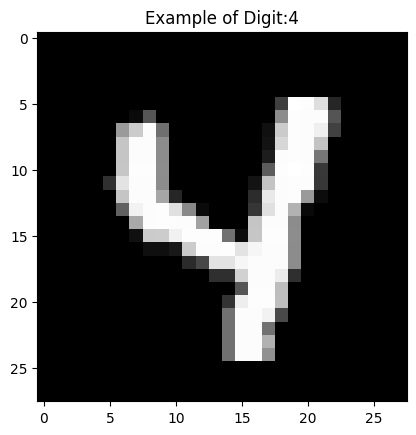

In [27]:
# 繪出圖表的預測結果
plt.figure()
plt.title("Example of Digit:" + str(Y_test_bk[i]))
plt.imshow(digit, cmap="gray")

In [28]:
# 預測結果的機率
print("Predicting ...")
probs = model_inference.predict(X_test_digit, batch_size=1)
print(probs)

Predicting ...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 896ms/step
[[1.2559163e-03 7.7211647e-04 4.3902241e-04 8.3410804e-04 9.9162769e-01
  1.5516098e-03 3.9421787e-04 4.3703368e-04 2.5285226e-03 1.5975299e-04]]


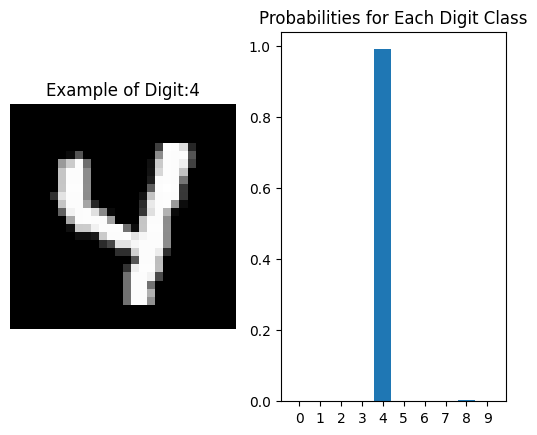

In [29]:
# 繪出圖表的預測結果
plt.figure()
plt.subplot(1,2,1)
plt.title("Example of Digit:" + str(Y_test_bk[i]))
plt.imshow(digit, cmap="gray")
plt.axis("off")
plt.subplot(1,2,2)
plt.title("Probabilities for Each Digit Class")
plt.bar(np.arange(10), probs.reshape(10), align="center")
plt.xticks(np.arange(10),np.arange(10).astype(str))
plt.show()

## 檢查辨識錯誤的數字圖檔

In [30]:
# 測試資料集的分類和機率的預測值
Y_pred_probs = model_inference.predict(X_test)     # 預測機率
Y_pred_classes= np.argmax(Y_pred_probs,axis=1)   # 轉成分類

313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 106ms/step


In [31]:
# 建立分類錯誤的 DataFrame 物件
df = pd.DataFrame({"label":Y_test_bk, "predict":Y_pred_classes})
df = df[Y_test_bk!=Y_pred_classes]  # 篩選出分類錯誤的資料
print(df.head()) # 看前五筆分類錯誤

      label  predict
321       2        7
582       8        2
882       9        4
947       8        9
1014      6        5


Index:  1393


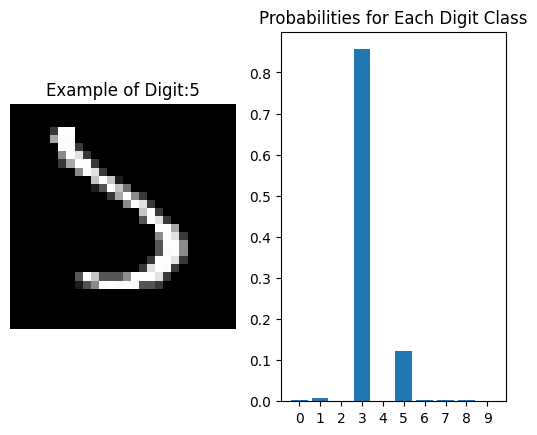

In [32]:
# 隨機選 1 個錯誤分類的數字索引
i = df.sample(n=1).index.values.astype(int)[0]
print("Index: ", i)
digit = X_test_bk[i].reshape(28, 28) 
# 繪出圖表的預測結果
plt.figure()
plt.subplot(1,2,1)
plt.title("Example of Digit:" + str(Y_test_bk[i]))
plt.imshow(digit, cmap="gray")
plt.axis("off")
plt.subplot(1,2,2)
plt.title("Probabilities for Each Digit Class")
plt.bar(np.arange(10), Y_pred_probs[i].reshape(10), align="center")
plt.xticks(np.arange(10),np.arange(10).astype(str))
plt.show()

In [33]:
# 預測錯誤的筆數
len(df)

40

In [34]:
# 作業計算公式
base = 80
score_upperB = 100
score_lowerB = 80
score = 100-((score_upperB-score_lowerB)*(len(df)/base))

print(score)

90.0
